# Xi Composition Map

Single-year cross-country scatter for selected xi composition metrics.

- x-axis: `xi`
- y-axis ratio mode:
  - `share` -> configurable via `share_metric` (`share`, `share_amp_1`, `share_amp_2`)
  - `amplification` -> `xi / xi_dir`
- choose a `benchmark_year` and optionally label selected countries
- set `include_all_countries = True` to highlight every available country in the selected year
- set `use_groupings = True` to color countries by your custom groups; highlights then label countries instead of recoloring them

In [93]:
from pathlib import Path
import os
import sys
import importlib

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(project_root)
src_path = str(project_root / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from io_networks.config import load_config
import io_networks.viz_xi as viz_xi
importlib.reload(viz_xi)

load_xi_data = viz_xi.load_xi_data
select_phase_map_countries = viz_xi.select_phase_map_countries
plot_xi_composition_map = viz_xi.plot_xi_composition_map

import matplotlib.pyplot as plt

In [ ]:
cfg = load_config('config/default.yaml')
variant = None  # None -> inferred from config
ratio_mode = 'share'  # 'share' or 'amplification'
share_metric = 'share'  # used when ratio_mode == 'share'
only_ok = True
benchmark_year = 2017
include_all_countries = False
use_groupings = False
highlight_countries = ["CHN", "VNM", "THA", "AGO", "NLD", "GBR", "NOR"]

# Highlight styling (edit here)
highlight_point_size = 75
highlight_label_fontsize = 15
highlight_colors = {
    'CHN': '#8eb8e5',
    'VNM': '#8eb8e5',
    'THA': '#8eb8e5',
    'AGO': '#4b637c',
    'NOR': '#c97a3d',
    'GBR': '#c97a3d',
    'NLD': '#c97a3d',
}

In [95]:
country_groups = {
    "Small Open Hubs": [
        "CHE", "ISL", "LUX", "CYP", "HKG", "SGP", "MLT", "COD",
    ],
    "European Advanced Core": [
        "AUT", "DEU", "FRA", "GBR", "ITA", "PRT", "SVN",
        "FIN", "SWE", "EST", "LVA", "DNK", "MAR", "TUR", "CRI", "KHM",
    ],
    "Manufacturing Exporters": [
        "CZE", "POL", "SVK", "KOR",
        "BGR", "BLR", "VNM", "UKR", "THA", "TWN", "KHM",
    ],
    "Resource Right-Tail Outliers": [
        "BRN", "EGY", "AGO", "ARE", "MYS", "JOR", "SAU", "IDN",
    ],
}


In [96]:
df = load_xi_data(cfg=cfg, variant=variant)
print('rows:', len(df))
print('years:', int(df['year'].min()), 'to', int(df['year'].max()))
if 'status' in df.columns:
    print('status counts:', df['status'].value_counts(dropna=False).to_dict())

rows: 2268
years: 1995 to 2022
status counts: {'ok': 2268}


In [97]:
available_years = sorted(int(y) for y in df['year'].dropna().unique())
print('available years:', available_years)
if benchmark_year not in available_years:
    raise ValueError(f'benchmark_year={benchmark_year} not found in available years')

auto_highlight_countries = select_phase_map_countries(
    df,
    ratio_mode=ratio_mode,
    share_metric=share_metric,
    only_ok=only_ok,
)
print('auto highlight countries:', auto_highlight_countries)

# Override manually if needed
highlight_countries = highlight_countries or auto_highlight_countries
if include_all_countries:
    df_highlight = df.copy()
    if only_ok and 'status' in df_highlight.columns:
        df_highlight = df_highlight[df_highlight['status'] == 'ok'].copy()
    highlight_countries = sorted(
        df_highlight.loc[df_highlight['year'] == benchmark_year, 'country']
        .dropna()
        .astype(str)
        .str.upper()
        .unique()
        .tolist()
    )

active_country_groups = country_groups if use_groupings else None

available years: [1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
auto highlight countries: ['USA', 'CHN', 'BGR', 'IND', 'CYP']


benchmark year rows: 81 from original: 2268


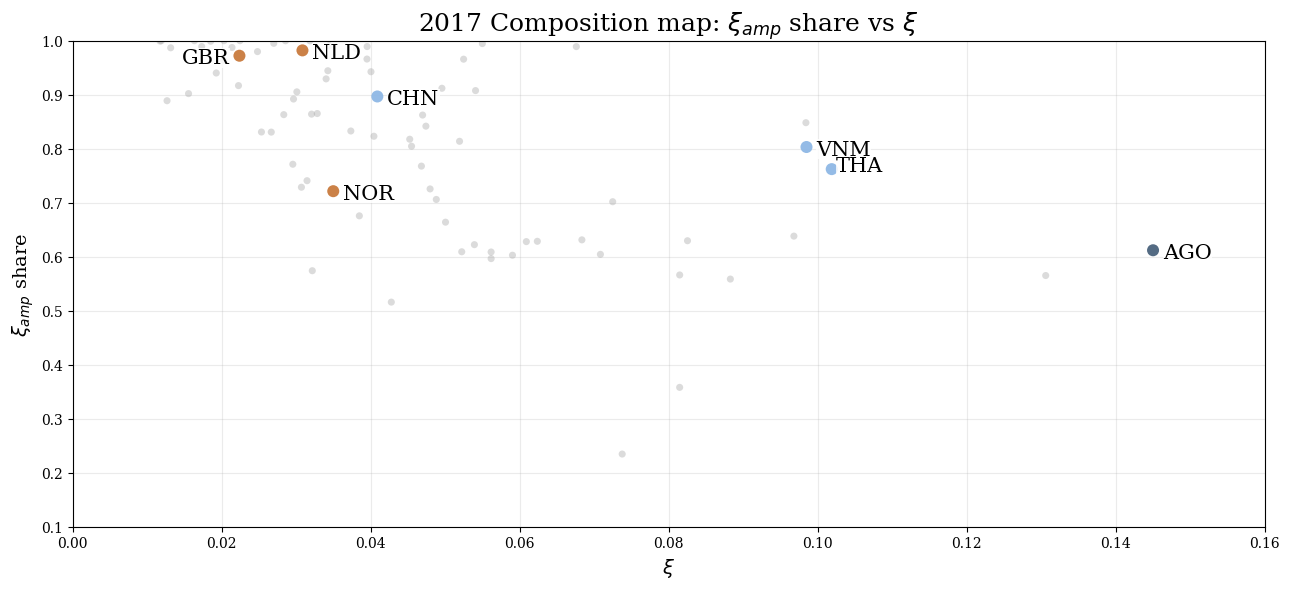

In [99]:
df_year = df[df['year'] == benchmark_year].copy()
print('benchmark year rows:', len(df_year), 'from original:', len(df))

ratio_label = share_metric if ratio_mode == 'share' else ratio_mode

fig, ax = plt.subplots(figsize=(13, 6))
plot_xi_composition_map(
    df_year,
    year=benchmark_year,
    ratio_mode=ratio_mode,
    share_metric=share_metric,
    highlight_countries=highlight_countries,
    country_groups=active_country_groups,
    only_ok=only_ok,
    title=rf'Composition map: {ratio_label} vs $\xi$ ({benchmark_year})',
    point_size_bg=26,
    point_size_hi=highlight_point_size,
    show_legend=False,
    highlight_colors=highlight_colors,
    highlight_label_fontsize=highlight_label_fontsize,
    ax=ax,
    label_dy_pts=-1.5
)

ax.set_xlim(0.00, 0.16)
ax.set_ylim(0.1, 1)

ax.set_ylabel(r"$\xi_{amp}$ share", fontfamily='serif', fontsize=14)
ax.set_xlabel(rf"$\xi$", fontfamily='serif', fontsize=14)
ax.set_title(r"2017 Composition map: $\xi_{amp}$ share vs $\xi$", fontfamily="serif", fontsize=18)

plt.tight_layout()
#plt.savefig('xi_amp_composition_map_2017.pdf', bbox_inches='tight', dpi=300)
plt.show()